In [16]:
import importlib
import sys
sys.path.append('../code')

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import pandas as pd

import SeaLevelContrib as slc

import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('retina')

In [17]:
importlib.reload(slc)

<module 'SeaLevelContrib' from 'C:\\Users\\kyrab\\Github\\SLBudget\\notebooks\\../code\\SeaLevelContrib.py'>

In [18]:
def rotate_longitude(ds):
    '''Rotate the longitude of an xarray dataset from [0,360] to [-180,180]'''
    
    if 'lon' in ds.dims:
        lon = 'lon'
    elif 'longitude' in ds.dims:
        lon = 'longitude'
    else:
        print('Longitude not found in dimensions')
        
    ds[lon] = np.where(ds[lon]>180, ds[lon]-360, ds[lon])
    ds = ds.reindex({ lon : np.sort(ds[lon])})
    
    return ds


In [19]:
import os

fpath = '../outputs/Gravis_Antarctica/Gravis_gre_clean.nc'
print(os.path.exists(fpath))
print(os.path.getsize(fpath))  # should be > 0 bytes


True
11938645


In [20]:


#union_mask = xr.where((landsea == 1) | (maskje == 1), 1, 0)

In [25]:
fred_dir = '../data/Frederikse2020/'
Fred_ant_ds = xr.open_dataset(f'{fred_dir}AIS.nc')
#Fred_ant_ds['AIS_rsl_mean'].isel(time=-1).plot()
#plt.show()


fred2 = rotate_longitude(Fred_ant_ds)
#display(fred2)
#fred2['AIS_rsl_mean'].isel(time=-1).plot()
#plt.show()
Gravis_dir = '../outputs/Gravis_Antarctica/'
Gravis_ant_ds = xr.open_dataset(f'{Gravis_dir}Gravis_Ant_clean.nc')
#display(Gravis_ant_ds)

#union_mask = xr.load_dataarray(f'{Gravis_dir}union_mask.nc')

#Optional: scale data by factor 1.2 or 1.1837950465122913
#Gravis_ant_ds['AIS_Gravis'] = Gravis_ant_ds['AIS_Gravis']*1.1837950465122913
#Gravis_ant_ds['Meanslr'] = Gravis_ant_ds['Meanslr']*1.1837950465122913

#display(Gravis_ant_ds)
Gravis_gre_ds = xr.open_dataset(f'{Gravis_dir}Gravis_Gre_clean.nc')
#display(Gravis_gre_ds)

#display(Fred_ant_ds['AIS_rsl_mean'])

#print(Gravis_ant_ds.where(Gravis_ant_ds==0) == Gravis_ant_ds.where(union_mask ==1))

#Gravis_ant_ds = Gravis_ant_ds.astype('float64')
  #Gravis_ant_ds2 = Gravis_ant_ds.where(Gravis_ant_ds != 0, np.nan)  #change the zeros to nan
  # Set values to NaN where landmask is 1
#Gravis_ant_ds = Gravis_ant_ds.where(union_mask != 1, np.nan)


#display(Gravis_ant_ds2)
#display(Fred_ant_ds)



#display(union_mask)

#union_mask.plot()


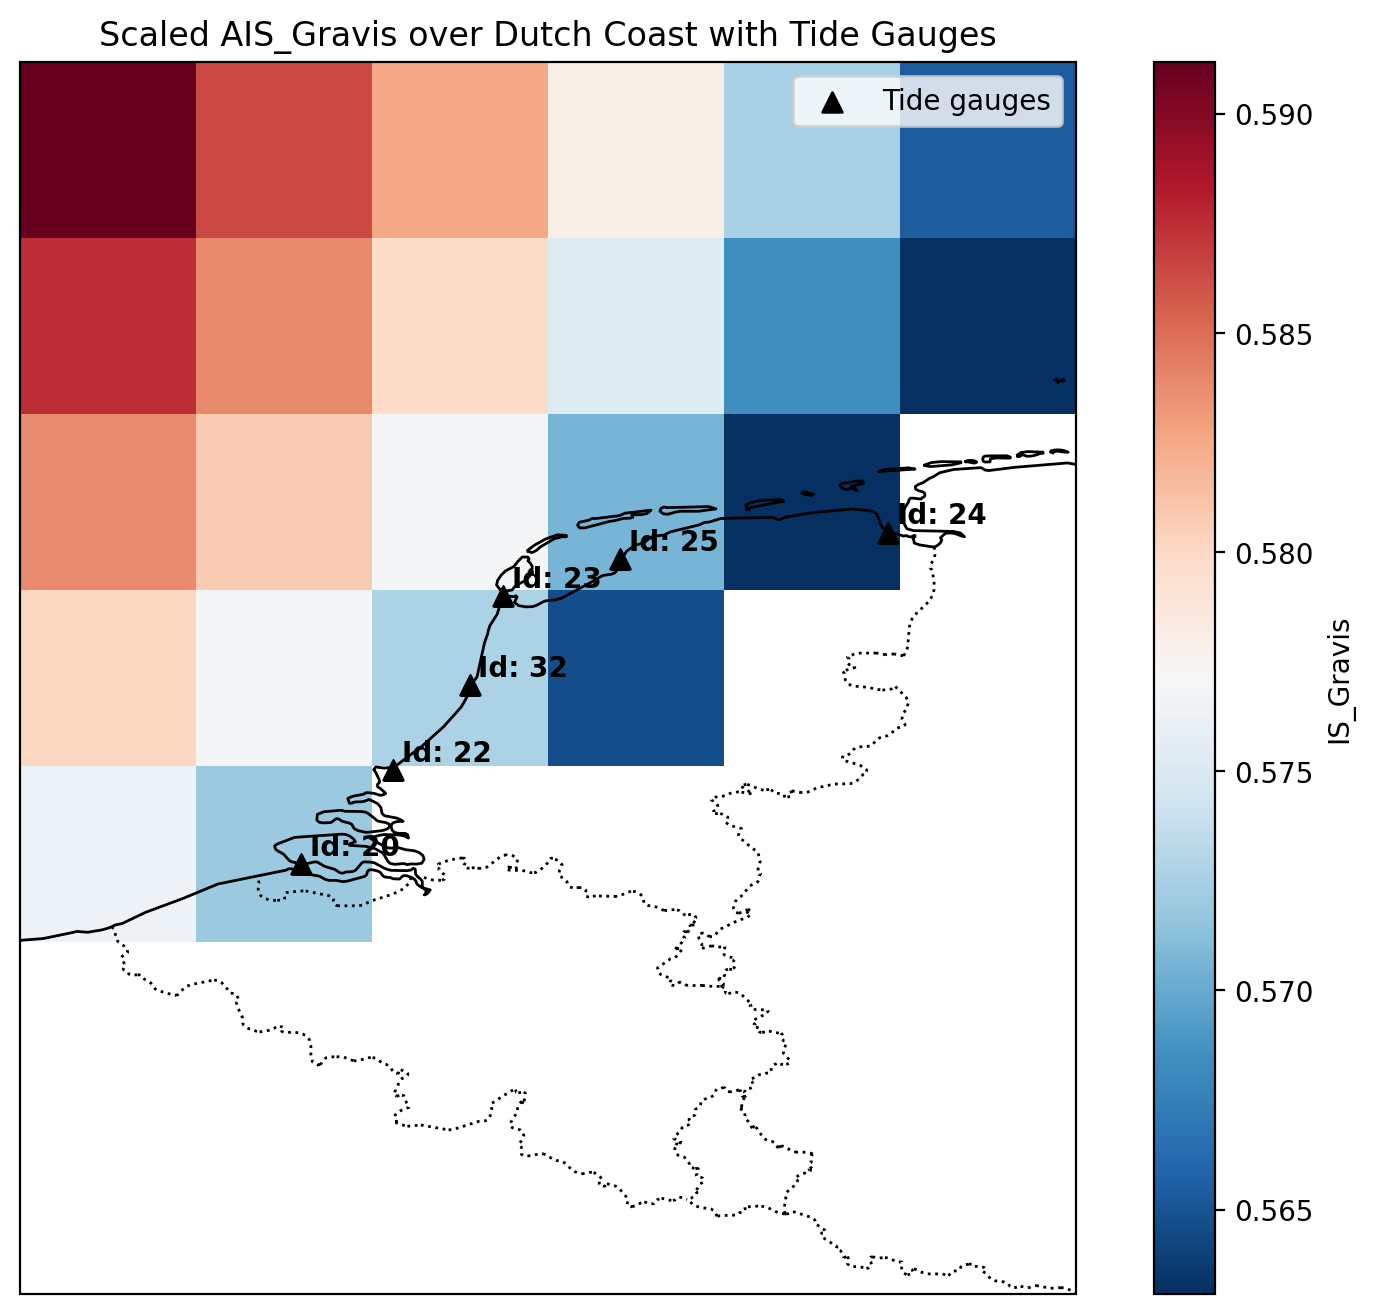

In [26]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

tg_id = [20, 22, 23, 24, 25, 32]
#Extract latitude and longitude from a tide gauge station from the list. 
tg_coord = slc.tg_lat_lon(tg_id[0])
#print(tg_coord)



# Extract coordinates
tg_coords = [slc.tg_lat_lon(tg) for tg in tg_id]
tg_lats = [c[0] for c in tg_coords]
tg_lons = [c[1] for c in tg_coords]


# Define region (Dutch coast)
lon_min, lon_max = 2,8 #3, 7
lat_min, lat_max = 49, 56 #51, 54

# Select region
da_region = Gravis_ant_ds['IS_Gravis'].sel(
    lon=slice(lon_min, lon_max),
    lat=slice(lat_min, lat_max)
)

# Pick a specific time if dataset has time dimension
if 'time' in da_region.dims:
    da_region = da_region.isel(time=-1)#-da_region.isel(time=0)  # Last time step minus first timestep (first timestep is already 0 so no need for that) 

# Plot
fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={'projection': ccrs.PlateCarree()})

# Plot GRAVIS data
im = da_region.plot(ax=ax, cmap='RdBu_r', add_colorbar=True)

# Add coastlines and borders
ax.coastlines(resolution='10m', zorder = 1 )
ax.add_feature(cfeature.BORDERS, linestyle=':')

# Plot tide gauge stations
ax.scatter(tg_lons, tg_lats, color='black', s=50, marker='^', label='Tide gauges', zorder=10)

# Add tide gauge IDs as labels
for lon, lat, tg in zip(tg_lons, tg_lats, tg_id):
    ax.text(lon + 0.05, lat + 0.05, 'Id: ' + str(tg), color='black', fontsize=10, weight='bold', zorder=10)

ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
ax.set_title('Scaled AIS_Gravis over Dutch Coast with Tide Gauges')
ax.legend()

plt.show()


In [28]:
tg_id = [20, 22, 23, 24, 25, 32]
#Extract latitude and longitude from a tide gauge station from the list. 
tg_coord = slc.tg_lat_lon(tg_id[0])
print(tg_coord)

TWS = slc.contrib_frederikse2020(tg_coord, 'tws', extrap=True)
ANT = slc.contrib_frederikse2020(tg_coord, 'AIS', extrap=True)
GRE = slc.contrib_frederikse2020(tg_coord, 'GrIS', extrap=True)
GLA = slc.contrib_frederikse2020(tg_coord, 'glac', extrap=True)

glo_steric_df = slc.contrib_frederikse2020_glob('GloSteric', extrap=True)


ds = Gravis_ant_ds
ds2 = Gravis_gre_ds

sel_da = ds['IS_Gravis'].ffill('lon', 3).bfill('lon', 3)
sel_da2 = ds2['IS_Gravis'].ffill('lon', 3).bfill('lon', 3)
# Convert from mm to cm not needed because is already in cm

loc_da = sel_da.sel(lat = tg_coord[0], 
                    lon = tg_coord[1], 
                    method = 'nearest')
loc_da2 = sel_da2.sel(lat = tg_coord[0], 
                    lon = tg_coord[1], 
                    method = 'nearest')

fr_name = {'tws' : 'TWS', 
       'AIS' : 'Antarctica', 
       'GrIS' : 'Greenland', 
       'glac' : 'Glaciers',
          'grav': 'Ant_gravis',
          'grav2': 'Gre_gravis'}


GRAVANT = loc_da.squeeze().reset_coords(drop=True).to_dataframe(name=fr_name['grav'])    
GRAVGRE = loc_da2.squeeze().reset_coords(drop=True).to_dataframe(name=fr_name['grav2'])    

''' 
EXTRAPOLATE OPTION
nby = 10
trend = np.polyfit(GRAVANT.index[-nby:], GRAVANT.iloc[-nby:], 1)
for i in range(7):
    GRAVANT.loc[GRAVANT.index.max() + 1] = (trend[1]+trend[0]*(GRAVANT.index.max()+1))
'''

display(GRAVANT*1.1837950465122913)
#display(ANT)




(np.float64(51.442222), np.float64(3.596111))


,Ant_gravis
time,
2002,0.000000
2003,0.029157
2004,0.059728
2005,0.070409
2006,0.058395
2007,0.101360
2008,0.183381
2009,0.168684
2010,0.219076


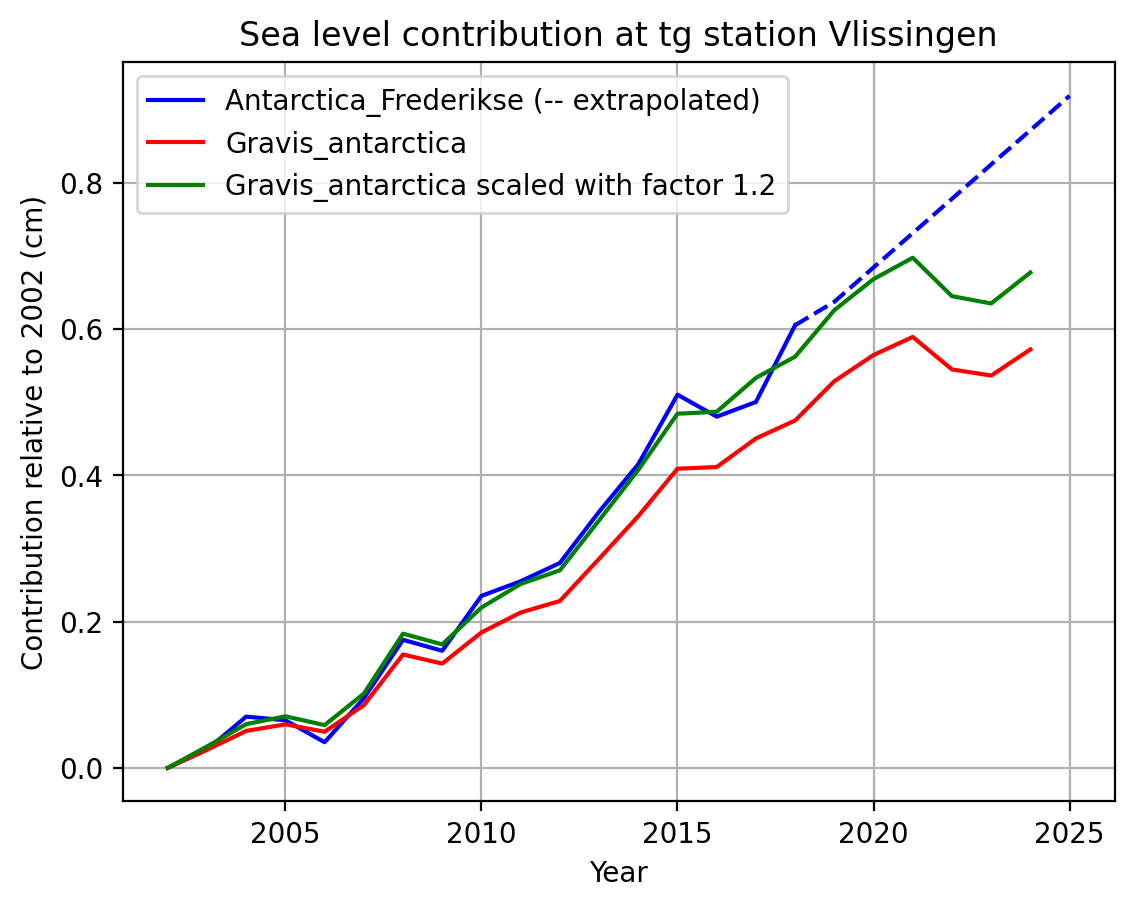

In [29]:
#plt.plot(TWS.loc[2000:], label='TWS')
plt.plot((ANT- ANT.loc[2002, "Antarctica"]).loc[2002:2018], label='Antarctica_Frederikse (-- extrapolated)', color='b')
plt.plot((ANT- ANT.loc[2002, "Antarctica"]).loc[2018:], color='b', linestyle='--')
#plt.plot(GRE.loc[2000:], label='Greenland')
#plt.plot(GLA.loc[2000:], label='Glaciers')
plt.plot(GRAVANT.loc[2002:], label='Gravis_antarctica', color='red')
plt.plot(GRAVANT.loc[2002:]*1.1837950465122913, label='Gravis_antarctica scaled with factor 1.2', color='green')
#plt.plot(glo_steric_df.loc[2000:], label='Global Steric')


plt.legend()
plt.xlabel('Year')
plt.title('Sea level contribution at tg station Vlissingen')
plt.ylabel('Contribution relative to 2002 (cm)')
plt.grid(True)
#plt.xlim(2017,2024)
#plt.ylim(0.45,0.8)
plt.show()


In [30]:
display(GRAVANT)

,Ant_gravis
time,
2002,0.000000
2003,0.024630
2004,0.050455
2005,0.059477
2006,0.049329
2007,0.085623
2008,0.154910
2009,0.142494
2010,0.185062


In [32]:
# Now for all stations: 

tg_id = [20, 22, 23, 24, 25, 32]  # Ise statopm 32 om stead of 22 because landsea mask does not overlap with 22 and 32 is in the closest cell

all_TWS = []
all_ANT = []
all_GRE = []
all_GLA = []
all_GRAVANT = []
all_GRAVGRE = []

for tg in tg_id: 
    tg_coord = slc.tg_lat_lon(tg)

    # Contributions from Frederikse 2020
    TWS_tg = slc.contrib_frederikse2020(tg_coord, 'tws', extrap=True)
    ANT_tg = slc.contrib_frederikse2020(tg_coord, 'AIS', extrap=True)
    GRE_tg = slc.contrib_frederikse2020(tg_coord, 'GrIS', extrap=True)
    GLA_tg = slc.contrib_frederikse2020(tg_coord, 'glac', extrap=True)

    all_TWS.append(TWS)
    all_ANT.append(ANT)
    all_GRE.append(GRE)
    all_GLA.append(GLA)

    sel_da = ds['IS_Gravis'].ffill('lon', 3).bfill('lon', 3)
    sel_da2 = ds2['IS_Gravis'].ffill('lon', 3).bfill('lon', 3)
    # Convert from mm to cm not needed because is already in cm

    loc_da = sel_da.sel(lat = tg_coord[0], 
                    lon = tg_coord[1], 
                    method = 'nearest')
    loc_da2 = sel_da2.sel(lat = tg_coord[0], 
                    lon = tg_coord[1], 
                    method = 'nearest')

    fr_name = {
        'tws' : 'TWS', 
        'AIS' : 'Antarctica', 
        'GrIS' : 'Greenland', 
        'glac' : 'Glaciers',
        'grav': 'Ant_gravis',
        'grav2': 'Gre_gravis'}

    # Was not here oeps.. GRAVANT = loc_da.squeeze().reset_coords(drop=True).to_dataframe(name=fr_name['grav'])
    GRAVANT = loc_da.squeeze().reset_coords(drop=True).to_dataframe(name=fr_name['grav'])    
    GRAVGRE = loc_da2.squeeze().reset_coords(drop=True).to_dataframe(name=fr_name['grav2'])  


    display(GRAVANT*1.1837950465122913)
    
    all_GRAVANT.append(GRAVANT)
    all_GRAVGRE.append(GRAVGRE)


#display(all_GRAVANT) 

# Helper function to compute mean across tide gauges
def mean_across_gauges(list_of_series):
    return pd.concat(list_of_series, axis=1).mean(axis=1)

# Compute mean time series for each contribution
mean_TWS = mean_across_gauges(all_TWS)
mean_ANT = mean_across_gauges(all_ANT)
mean_GRE = mean_across_gauges(all_GRE)
mean_GLA = mean_across_gauges(all_GLA)
mean_GRAVANT = mean_across_gauges(all_GRAVANT)
mean_GRAVGRE = mean_across_gauges(all_GRAVGRE)

# Combine all mean series into a single dataframe
mean_df = pd.DataFrame({
    'TWS_mean': mean_TWS,
    'Antarctica_mean': mean_ANT,
    'Greenland_mean': mean_GRE,
    'Glaciers_mean': mean_GLA,
    'Ant_gravis_mean': mean_GRAVANT,
    'Gre_gravis_mean': mean_GRAVGRE
})



# Ensure the index is numeric or datetime
mean_df.index = pd.to_numeric(mean_df.index, errors='coerce')



display(mean_df.loc[2002:])

,Ant_gravis
time,
2002,0.000000
2003,0.029157
2004,0.059728
2005,0.070409
2006,0.058395
2007,0.101360
2008,0.183381
2009,0.168684
2010,0.219076


,Ant_gravis
time,
2002,0.000000
2003,0.029157
2004,0.059728
2005,0.070409
2006,0.058395
2007,0.101360
2008,0.183381
2009,0.168684
2010,0.219076


,Ant_gravis
time,
2002,0.000000
2003,0.029106
2004,0.059746
2005,0.070374
2006,0.058355
2007,0.101369
2008,0.183704
2009,0.168776
2010,0.219284


,Ant_gravis
time,
2002,0.000000
2003,0.028744
2004,0.058905
2005,0.069117
2006,0.057154
2007,0.099715
2008,0.181500
2009,0.165821
2010,0.215580


,Ant_gravis
time,
2002,0.000000
2003,0.029018
2004,0.059579
2005,0.070045
2006,0.058011
2007,0.100987
2008,0.183388
2009,0.168102
2010,0.218479


,Ant_gravis
time,
2002,0.000000
2003,0.029106
2004,0.059746
2005,0.070374
2006,0.058355
2007,0.101369
2008,0.183704
2009,0.168776
2010,0.219284


,TWS_mean,Antarctica_mean,Greenland_mean,Glaciers_mean,Ant_gravis_mean,Gre_gravis_mean
time,,,,,,
2002,0.185000,-0.250000,-0.065000,-0.335000,0.000000,0.000000
2003,0.085000,-0.225000,-0.055000,-0.280000,0.024538,0.009851
2004,0.000000,-0.180000,-0.050000,-0.220000,0.050323,0.013824
2005,0.120000,-0.185000,-0.050000,-0.180000,0.059234,0.011643
2006,-0.010000,-0.215000,-0.050000,-0.120000,0.049089,0.015205
2007,-0.025000,-0.155000,-0.040000,-0.080000,0.085341,0.019718
2008,-0.060000,-0.075000,-0.030000,-0.050000,0.154737,0.032020
2009,-0.090000,-0.090000,-0.015000,-0.005000,0.142035,0.044154
2010,0.055000,-0.015000,0.000000,0.060000,0.184545,0.054499


In [33]:
display(mean_df.loc[2002:]*1.1837950465122913)

,TWS_mean,Antarctica_mean,Greenland_mean,Glaciers_mean,Ant_gravis_mean,Gre_gravis_mean
time,,,,,,
2002,0.219002,-0.295949,-0.076947,-0.396571,0.000000,0.000000
2003,0.100623,-0.266354,-0.065109,-0.331463,0.029048,0.011662
2004,0.000000,-0.213083,-0.059190,-0.260435,0.059572,0.016365
2005,0.142055,-0.219002,-0.059190,-0.213083,0.070121,0.013783
2006,-0.011838,-0.254516,-0.059190,-0.142055,0.058111,0.017999
2007,-0.029595,-0.183488,-0.047352,-0.094704,0.101027,0.023342
2008,-0.071028,-0.088785,-0.035514,-0.059190,0.183176,0.037905
2009,-0.106542,-0.106542,-0.017757,-0.005919,0.168140,0.052270
2010,0.065109,-0.017757,0.000000,0.071028,0.218463,0.064516


In [34]:
Ant_combined = mean_df['Antarctica_mean'].copy()
#display(Ant_combined.loc[2002:2024])
Ant_combined.loc[2002:] = ((mean_df['Ant_gravis_mean'] + mean_df['Antarctica_mean'].loc[2002]) + mean_df['Antarctica_mean'])/2  #takes the mean where there is data twice
#display(Ant_combined.loc[2002:2024])
Ant_combined.loc[2018:] = mean_df['Ant_gravis_mean'] - mean_df['Ant_gravis_mean'].loc[2018] + Ant_combined.loc[2018]  # from 2018, take gravis data but force 2018 on the mean


Gre_combined = mean_df['Greenland_mean'].copy()


Gre_combined.loc[2002:] = ((mean_df['Gre_gravis_mean'] + mean_df['Greenland_mean'].loc[2002]) + mean_df['Greenland_mean'])/2  #takes the mean where there is data twice
#display(Ant_combined.loc[2002:2024])
Gre_combined.loc[2018:] = mean_df['Gre_gravis_mean'] - mean_df['Gre_gravis_mean'].loc[2018] + Gre_combined.loc[2018]  # from 2018, take gravis data but force 2018 on the mean



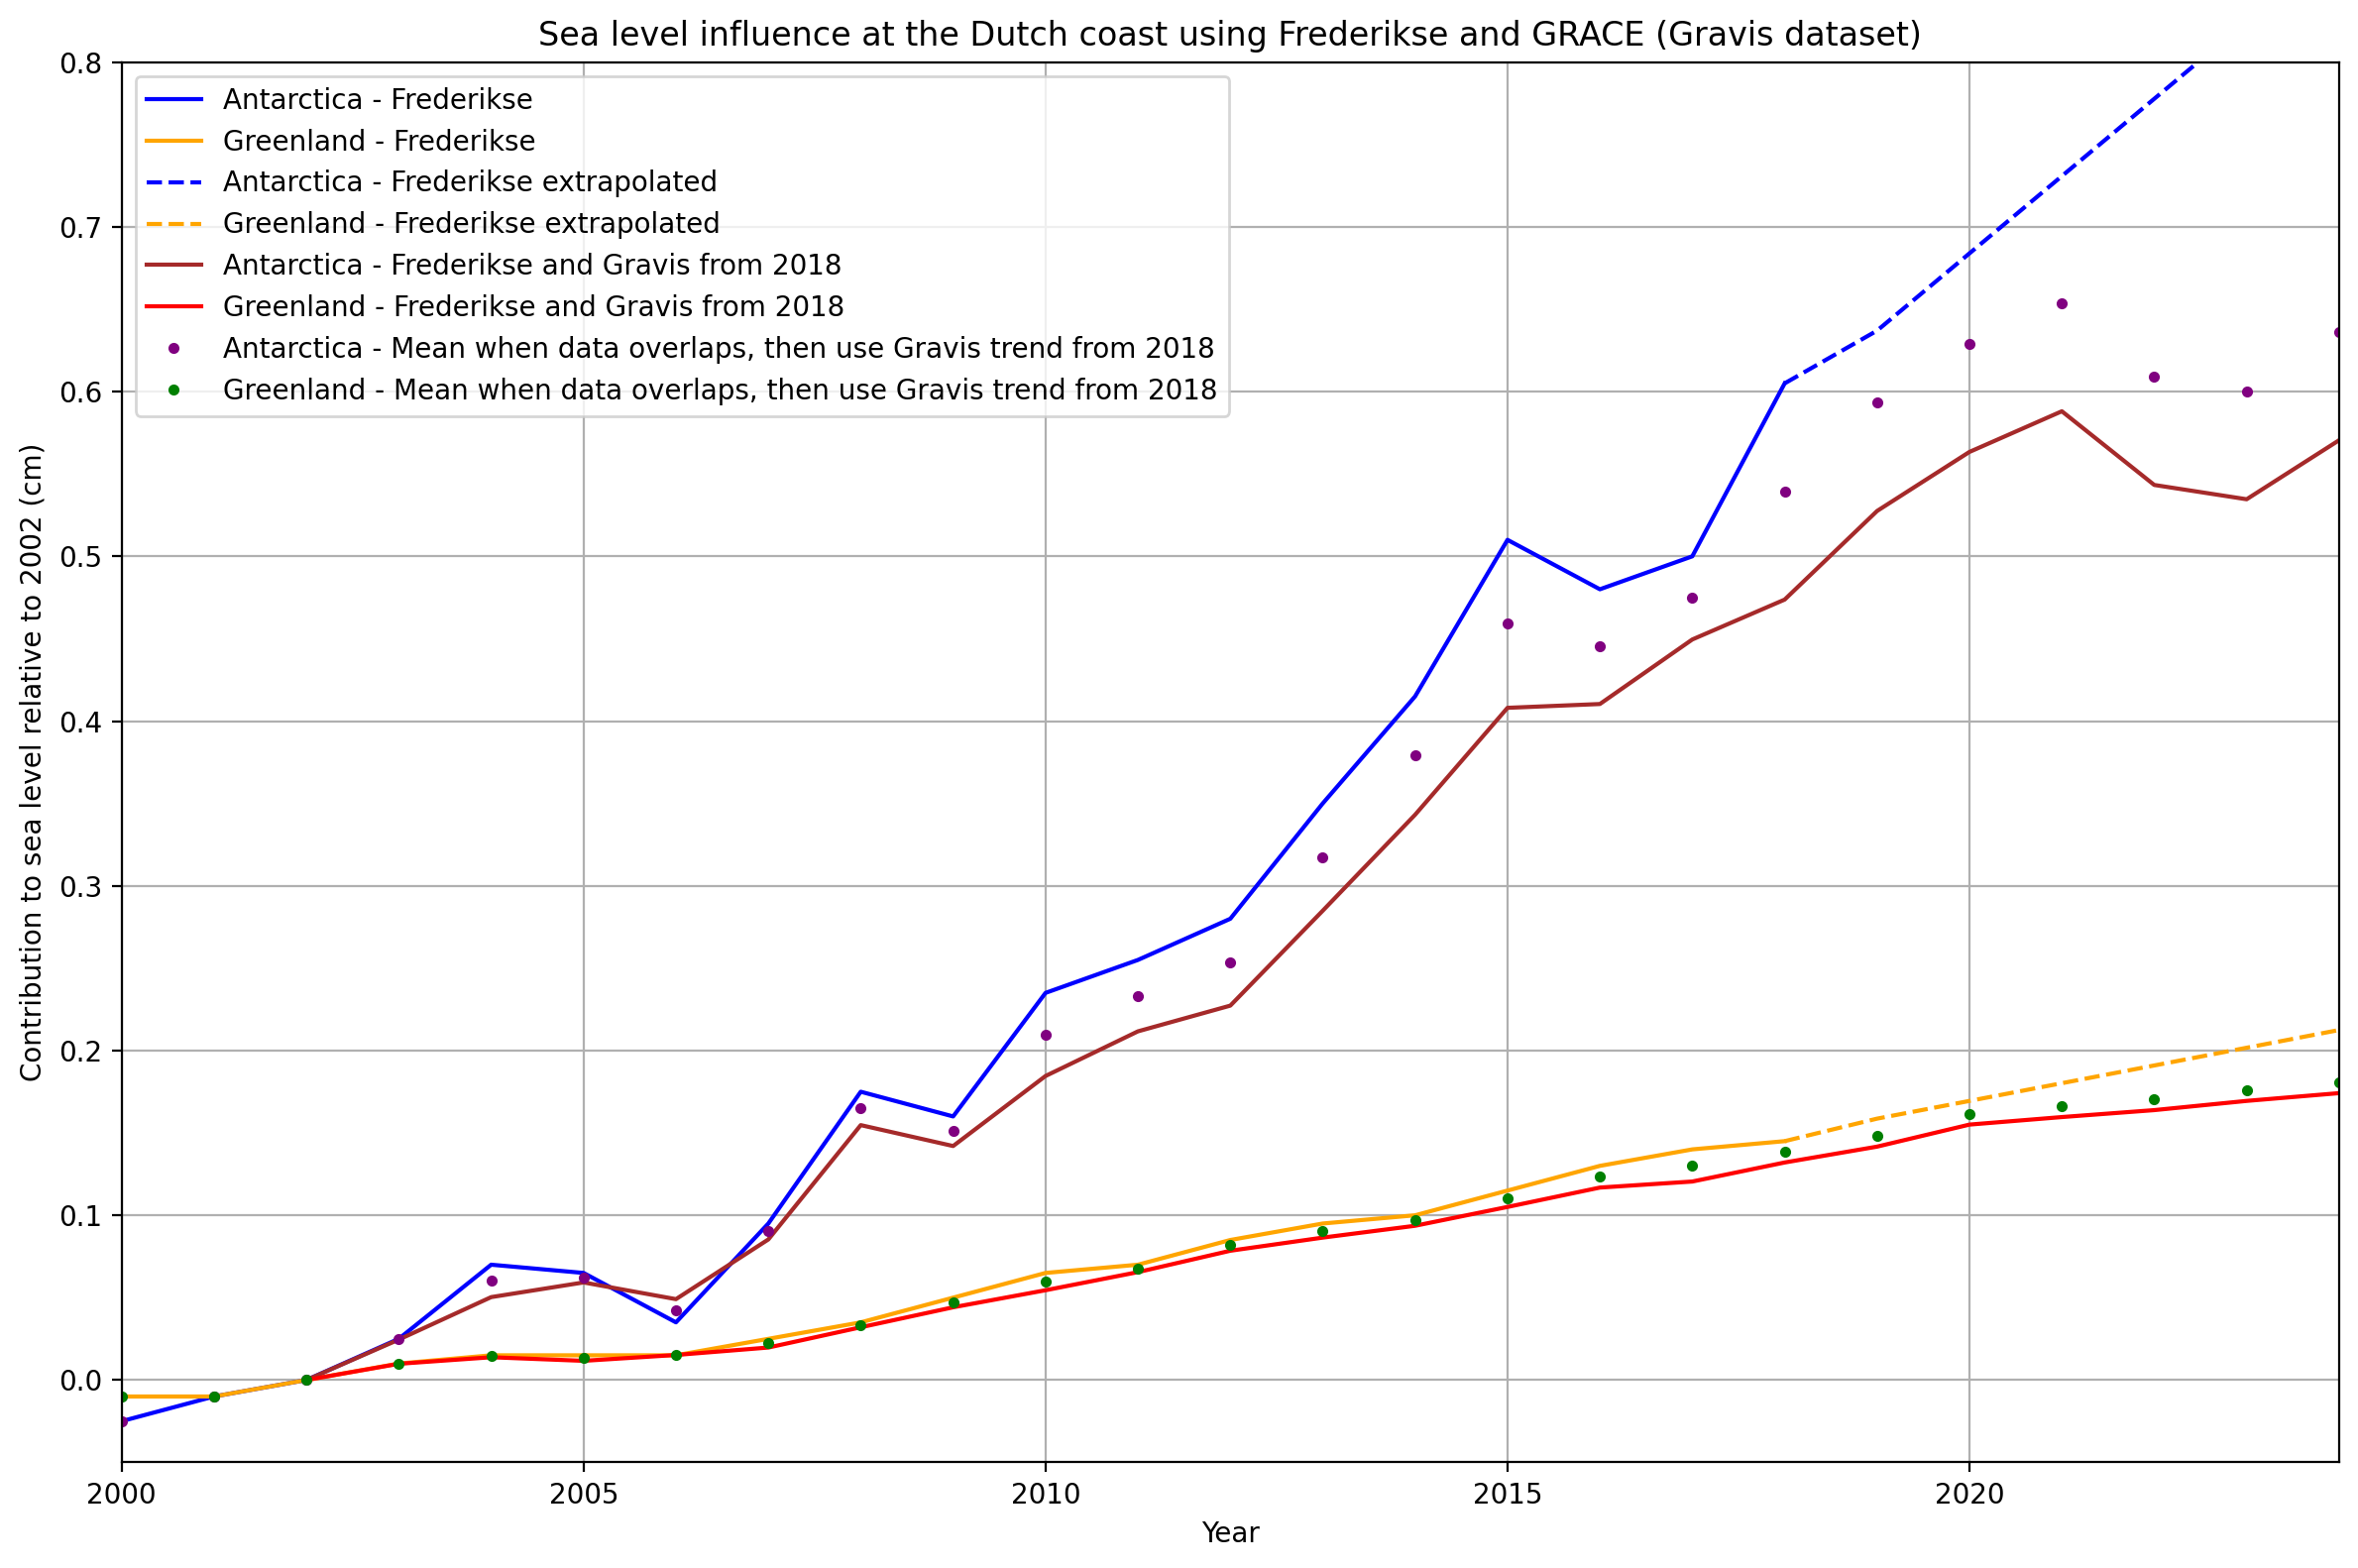

In [35]:
#display(GRAVANT)
#display(mean_df)



plt.figure(figsize=(12,8))



# Plot each series relative to 2002 from mean_df
#plt.plot(mean_df['TWS_mean'], label='TWS')
plt.plot((mean_df['Antarctica_mean'] - mean_df['Antarctica_mean'].loc[2002]).loc[:2018] , label='Antarctica - Frederikse', color='blue')
plt.plot((mean_df['Greenland_mean'] - mean_df['Greenland_mean'].loc[2002]).loc[:2018] , label='Greenland - Frederikse', color='orange')
plt.plot((mean_df['Antarctica_mean'] - mean_df['Antarctica_mean'].loc[2002]).loc[2018:] , label='Antarctica - Frederikse extrapolated', linestyle='--', color='blue')
plt.plot((mean_df['Greenland_mean'] - mean_df['Greenland_mean'].loc[2002]).loc[2018:] , label='Greenland - Frederikse extrapolated', linestyle='--', color='orange')
#plt.plot(mean_df['Glaciers_mean'] , label='Glaciers')
plt.plot(((mean_df['Ant_gravis_mean'] + mean_df['Antarctica_mean'].loc[2002])- (mean_df['Ant_gravis_mean'].loc[2002] + mean_df['Antarctica_mean'].loc[2002])), color='brown', linestyle='-', label='Antarctica - Frederikse and Gravis from 2018')
plt.plot(((mean_df['Gre_gravis_mean'] + mean_df["Greenland_mean"].loc[2002]) - (mean_df['Gre_gravis_mean'].loc[2002] + mean_df["Greenland_mean"].loc[2002])), color='red', linestyle='-', label='Greenland - Frederikse and Gravis from 2018')
plt.plot(Ant_combined - Ant_combined.loc[2002], label='Antarctica - Mean when data overlaps, then use Gravis trend from 2018', marker='.', linestyle='', color='purple') 
plt.plot(Gre_combined - Gre_combined.loc[2002], label='Greenland - Mean when data overlaps, then use Gravis trend from 2018', marker='.', linestyle='' ,color='green') 

plt.xlabel('Year')
plt.ylabel('Contribution to sea level relative to 2002 (cm)')
plt.title('Sea level influence at the Dutch coast using Frederikse and GRACE (Gravis dataset)')
plt.legend()
plt.grid(True)
plt.xlim(2000,2024)
plt.ylim(-0.05, 0.8)
plt.tight_layout()
plt.show()


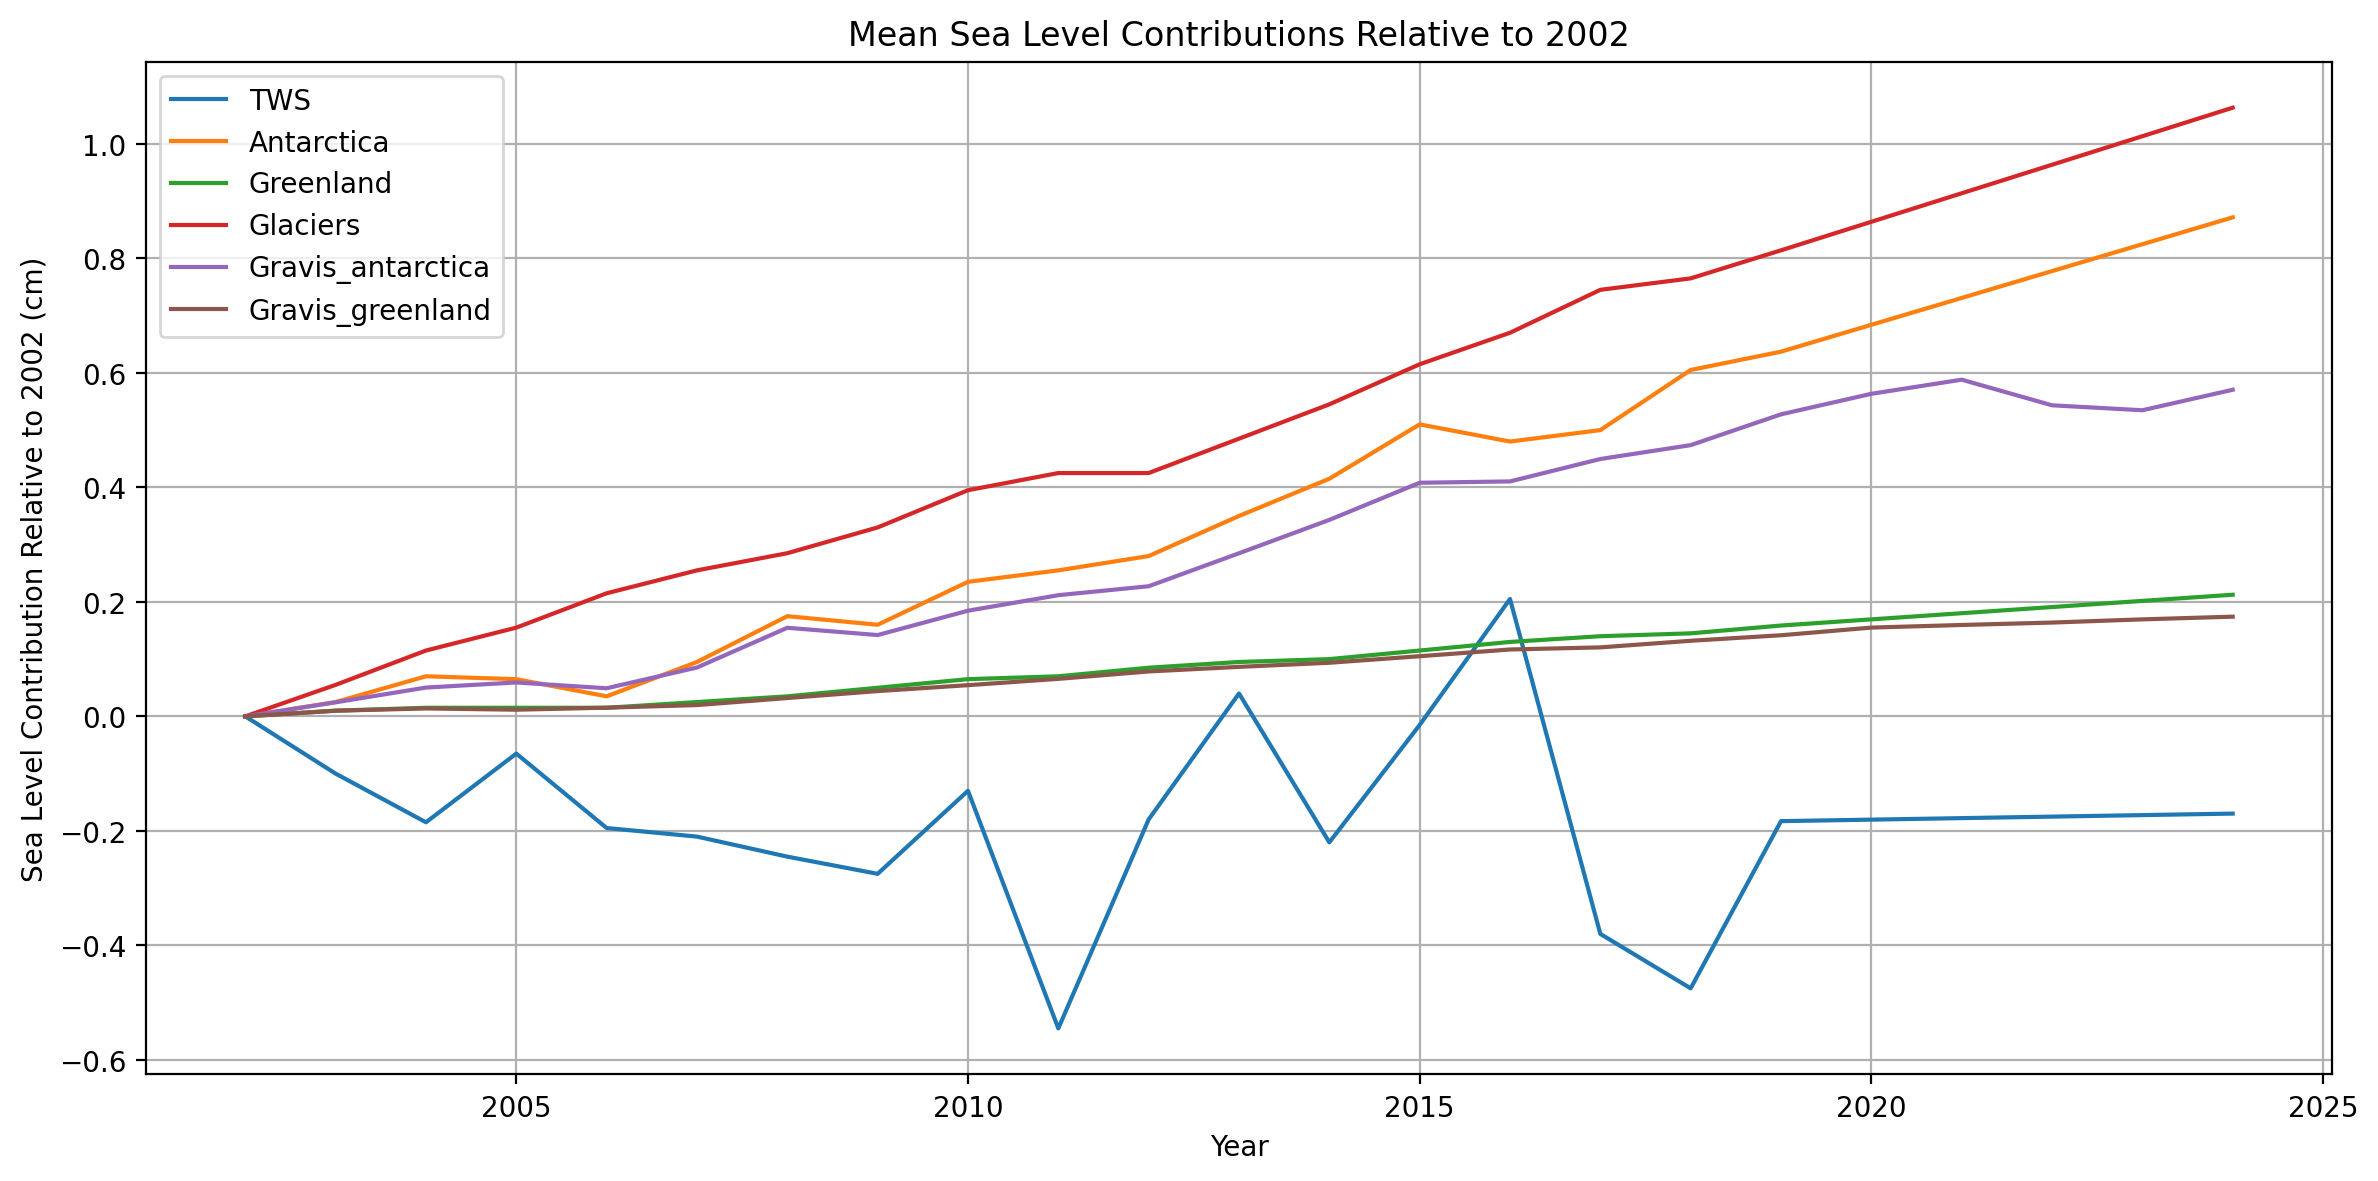

In [36]:



# Filter the years 2002–2024
mean_df_filtered = mean_df.loc[(mean_df.index >= 2002) & (mean_df.index <= 2024)]

import matplotlib.pyplot as plt

# Define the reference year (or custom value) for each series
ref_vals = {
    'TWS': 2002,
    'Antarctica': 2002,
    'Greenland': 2002,
    'Glaciers': 2002,
    'Gravis_antarctica': 2002,
    'Gravis_greenland': 2002
}

plt.figure(figsize=(12,6))

# Plot each series relative to 2002 from mean_df
plt.plot((mean_df_filtered['TWS_mean'] - mean_df_filtered['TWS_mean'].loc[2002]).loc[2002:], label='TWS')
plt.plot((mean_df_filtered['Antarctica_mean'] - mean_df_filtered['Antarctica_mean'].loc[2002]).loc[2002:], label='Antarctica')
plt.plot((mean_df_filtered['Greenland_mean'] - mean_df_filtered['Greenland_mean'].loc[2002]).loc[2002:], label='Greenland')
plt.plot((mean_df_filtered['Glaciers_mean'] - mean_df_filtered['Glaciers_mean'].loc[2002]).loc[2002:], label='Glaciers')
plt.plot((mean_df_filtered['Ant_gravis_mean'] - mean_df_filtered['Ant_gravis_mean'].loc[2002]).loc[2002:], label='Gravis_antarctica')
plt.plot((mean_df_filtered['Gre_gravis_mean'] - mean_df_filtered['Gre_gravis_mean'].loc[2002]).loc[2002:], label='Gravis_greenland')

plt.xlabel('Year')
plt.ylabel('Sea Level Contribution Relative to 2002 (cm)')
plt.title('Mean Sea Level Contributions Relative to 2002')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


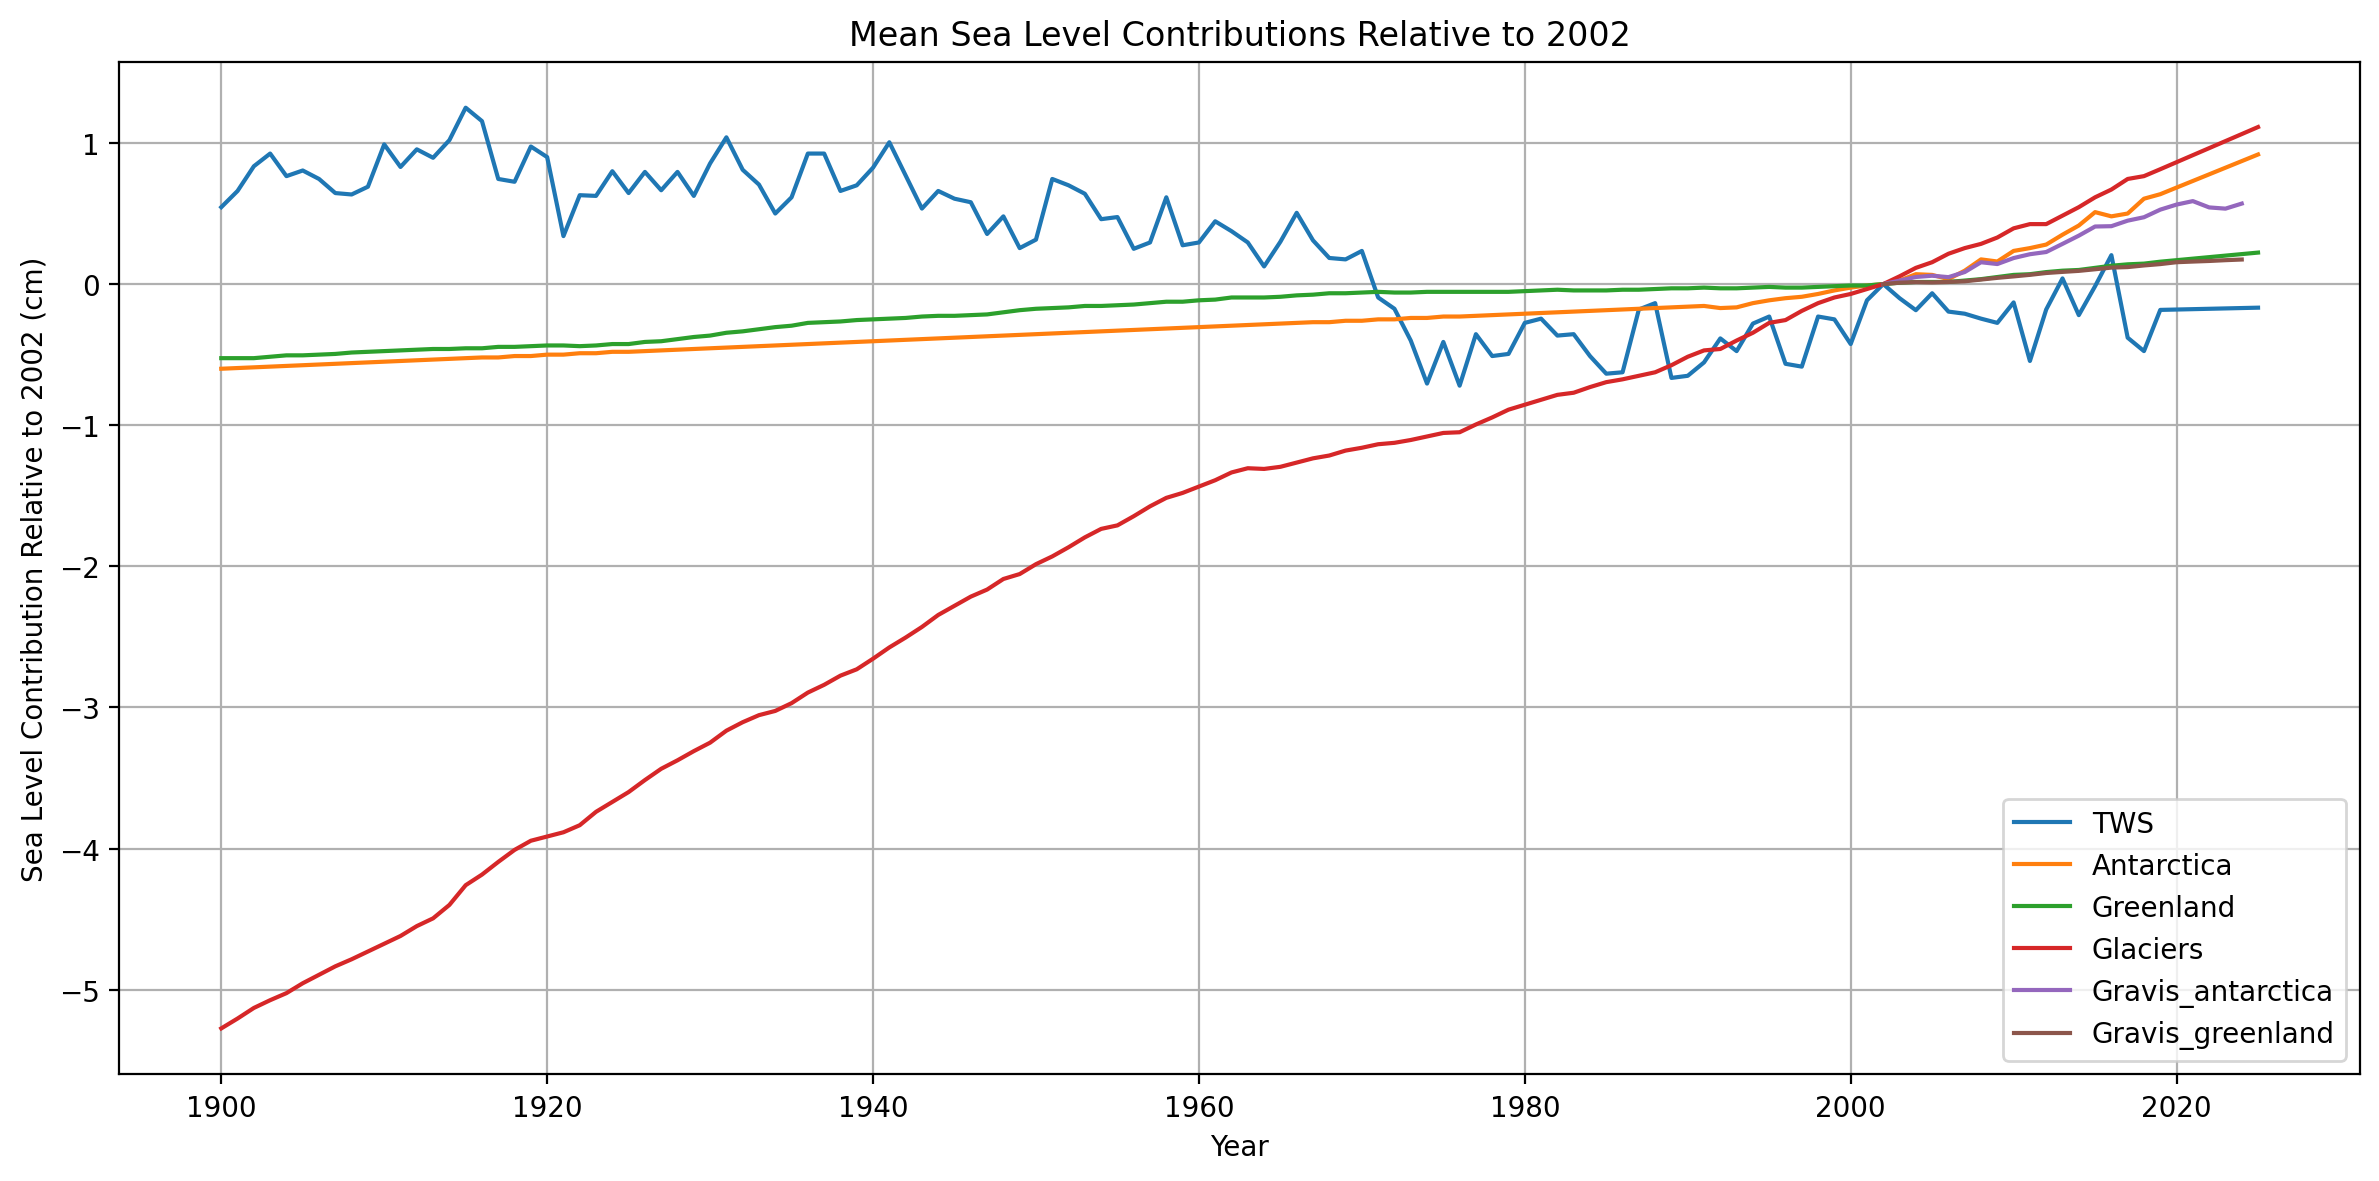

In [37]:
plt.figure(figsize=(12,6))

# Plot each series relative to 2002 from mean_df
plt.plot((mean_df['TWS_mean'] - mean_df['TWS_mean'].loc[2002]), label='TWS')
plt.plot((mean_df['Antarctica_mean'] - mean_df['Antarctica_mean'].loc[2002]), label='Antarctica')
plt.plot((mean_df['Greenland_mean'] - mean_df['Greenland_mean'].loc[2002]), label='Greenland')
plt.plot((mean_df['Glaciers_mean'] - mean_df['Glaciers_mean'].loc[2002]), label='Glaciers')
plt.plot((mean_df['Ant_gravis_mean'] - mean_df['Ant_gravis_mean'].loc[2002]), label='Gravis_antarctica')
plt.plot((mean_df['Gre_gravis_mean'] - mean_df['Gre_gravis_mean'].loc[2002]), label='Gravis_greenland')

plt.xlabel('Year')
plt.ylabel('Sea Level Contribution Relative to 2002 (cm)')
plt.title('Mean Sea Level Contributions Relative to 2002')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


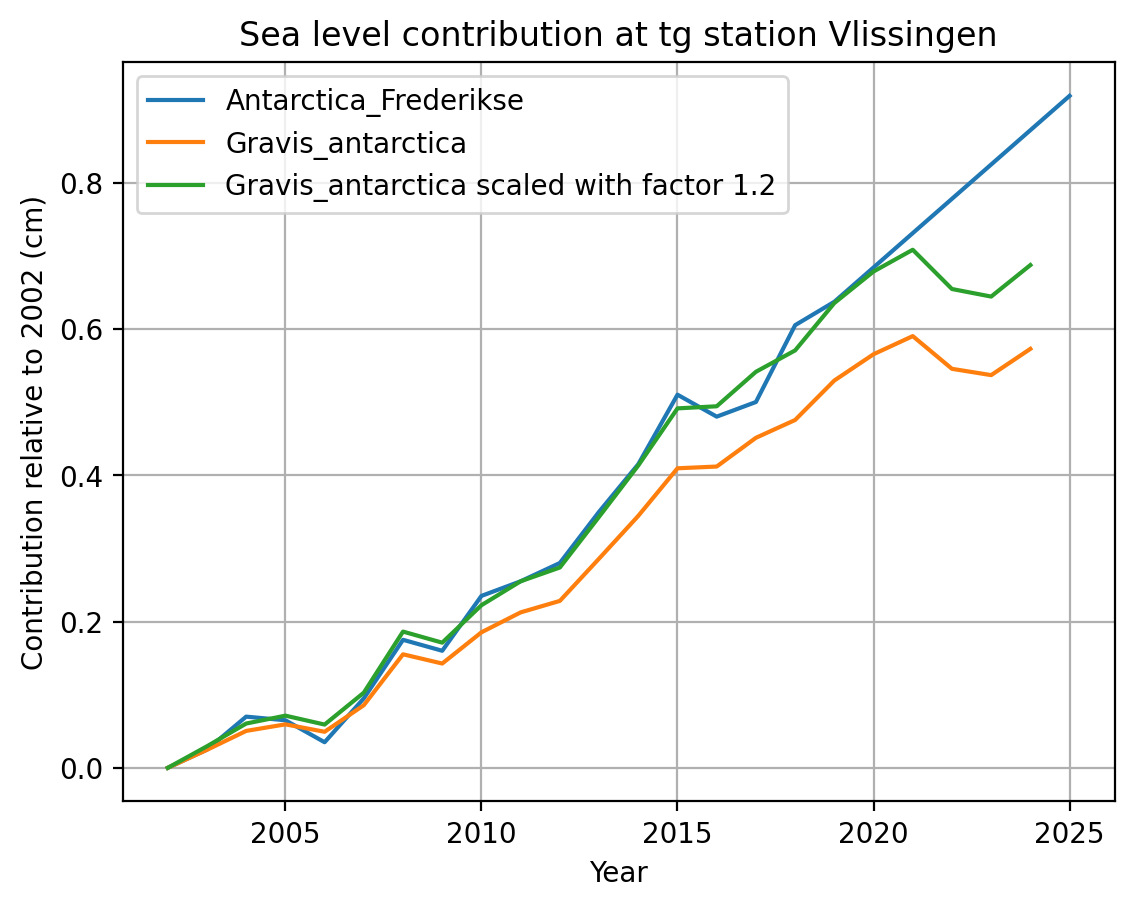

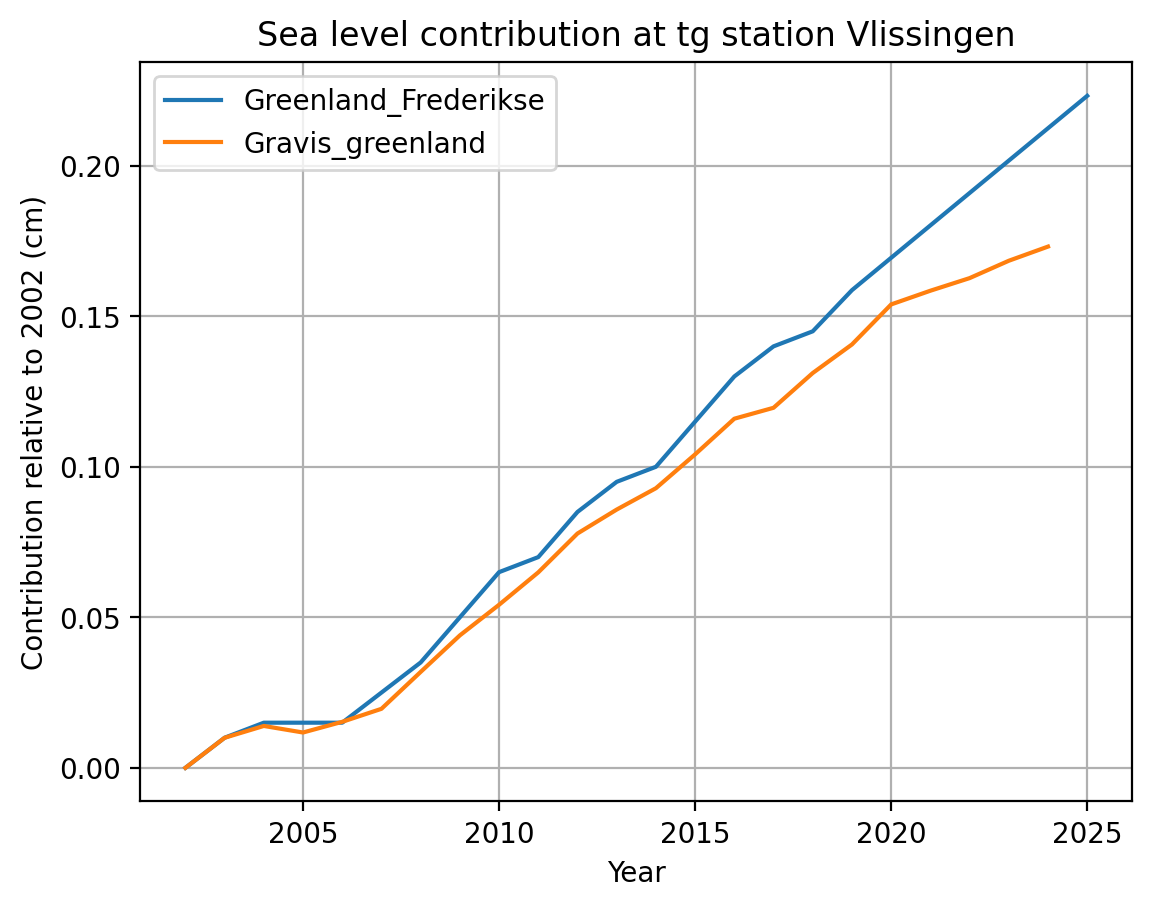

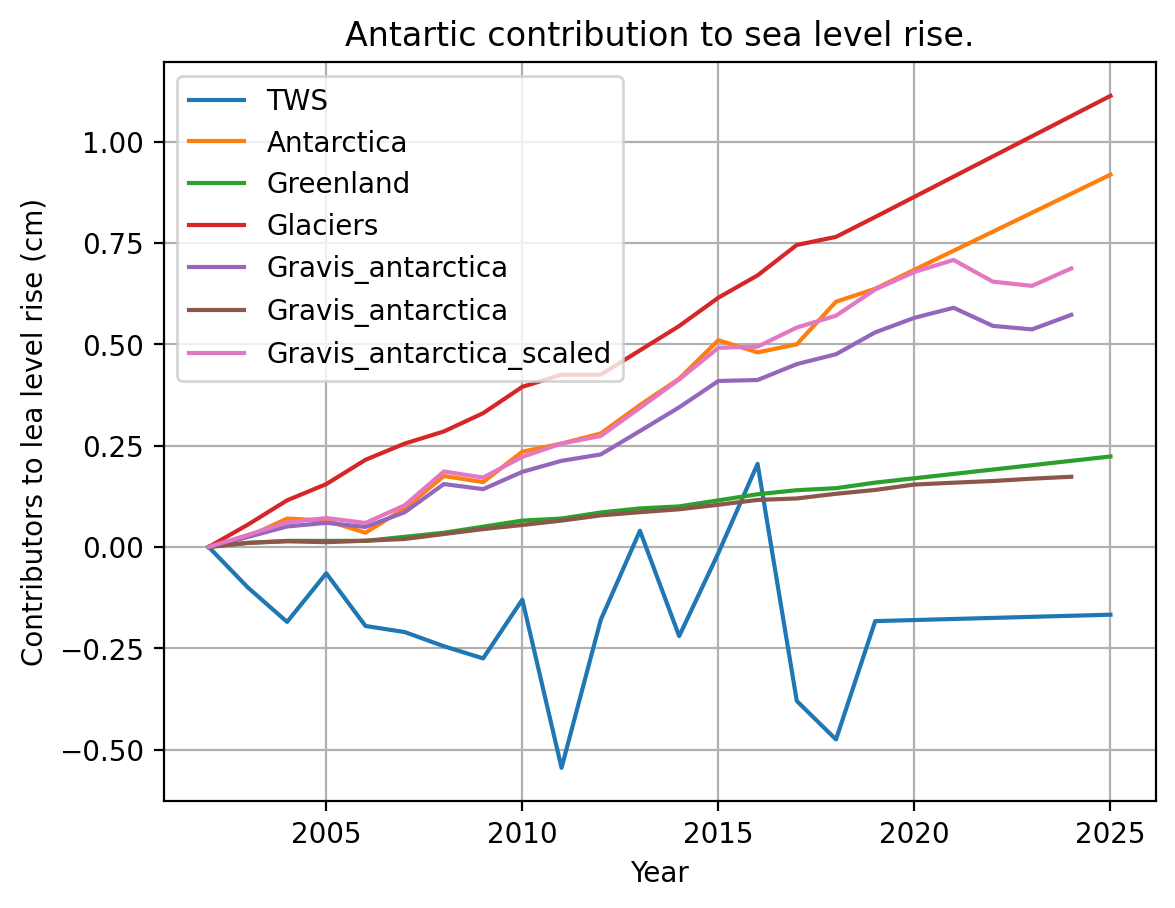

In [38]:
#plt.plot(TWS.loc[2000:], label='TWS')
plt.plot((ANT- ANT.loc[2002, "Antarctica"]).loc[2002:], label='Antarctica_Frederikse')
#plt.plot((ANT- ANT.loc[2002, "Antarctica"]).loc[2018:], label='Antarctica_Frederikse')
#plt.plot(GRE.loc[2000:], label='Greenland')
#plt.plot(GLA.loc[2000:], label='Glaciers')
plt.plot(GRAVANT.loc[2002:], label='Gravis_antarctica')
plt.plot(GRAVANT.loc[2002:]*1.2, label='Gravis_antarctica scaled with factor 1.2')
#plt.plot(glo_steric_df.loc[2000:], label='Global Steric')




plt.legend()
plt.xlabel('Year')
plt.title('Sea level contribution at tg station Vlissingen')
plt.ylabel('Contribution relative to 2002 (cm)')
plt.grid(True)
plt.show()




plt.plot((GRE- GRE.loc[2002, "Greenland"]).loc[2002:], label='Greenland_Frederikse')
#plt.plot(GRE.loc[2000:], label='Greenland')
#plt.plot(GLA.loc[2000:], label='Glaciers')
plt.plot(GRAVGRE.loc[2002:], label='Gravis_greenland')
#plt.plot(glo_steric_df.loc[2000:], label='Global Steric')




plt.legend()
plt.xlabel('Year')
plt.title('Sea level contribution at tg station Vlissingen')
plt.ylabel('Contribution relative to 2002 (cm)')
plt.grid(True)
plt.show()




plt.plot((TWS-TWS.loc[2002, "TWS"]).loc[2002:], label='TWS')
plt.plot((ANT- ANT.loc[2002, "Antarctica"]).loc[2002:], label='Antarctica')
plt.plot((GRE-GRE.loc[2002, "Greenland"]).loc[2002:], label='Greenland')
plt.plot((GLA-GLA.loc[2002, "Glaciers"]).loc[2002:], label='Glaciers')
plt.plot(GRAVANT.loc[2002:], label='Gravis_antarctica')
plt.plot(GRAVGRE.loc[2002:], label='Gravis_antarctica')
plt.plot(GRAVANT.loc[2002:]*1.2, label='Gravis_antarctica_scaled')
#plt.plot((glo_steric_df-glo_steric_df.loc[2002, 'Global Steric']).loc[2002:], label='Global Steric')




plt.legend()
plt.xlabel('Year')
plt.ylabel('Contributors to lea level rise (cm)')
plt.title('Antartic contribution to sea level rise.')
plt.grid(True)
plt.show()


,Sea level rise vlissingen,Sea level rise dutch coast,Mean sea level rise,Fraction (sea level rise / global mean ),Fraction (sea level rise dutch / global mean )
time,,,,,
2002,0.000000,0.000000,0.000000,NaN,NaN
2003,0.024587,0.024538,0.021933,1.121016,1.118799
2004,0.050470,0.050323,0.047691,1.058272,1.055191
2005,0.059448,0.059234,0.057078,1.041521,1.037782
2006,0.049295,0.049089,0.048500,1.016385,1.012130
2007,0.085630,0.085341,0.083262,1.028445,1.024971
2008,0.155182,0.154737,0.149561,1.037583,1.034604
2009,0.142572,0.142035,0.146366,0.974076,0.970408
2010,0.185238,0.184545,0.190999,0.969837,0.966207


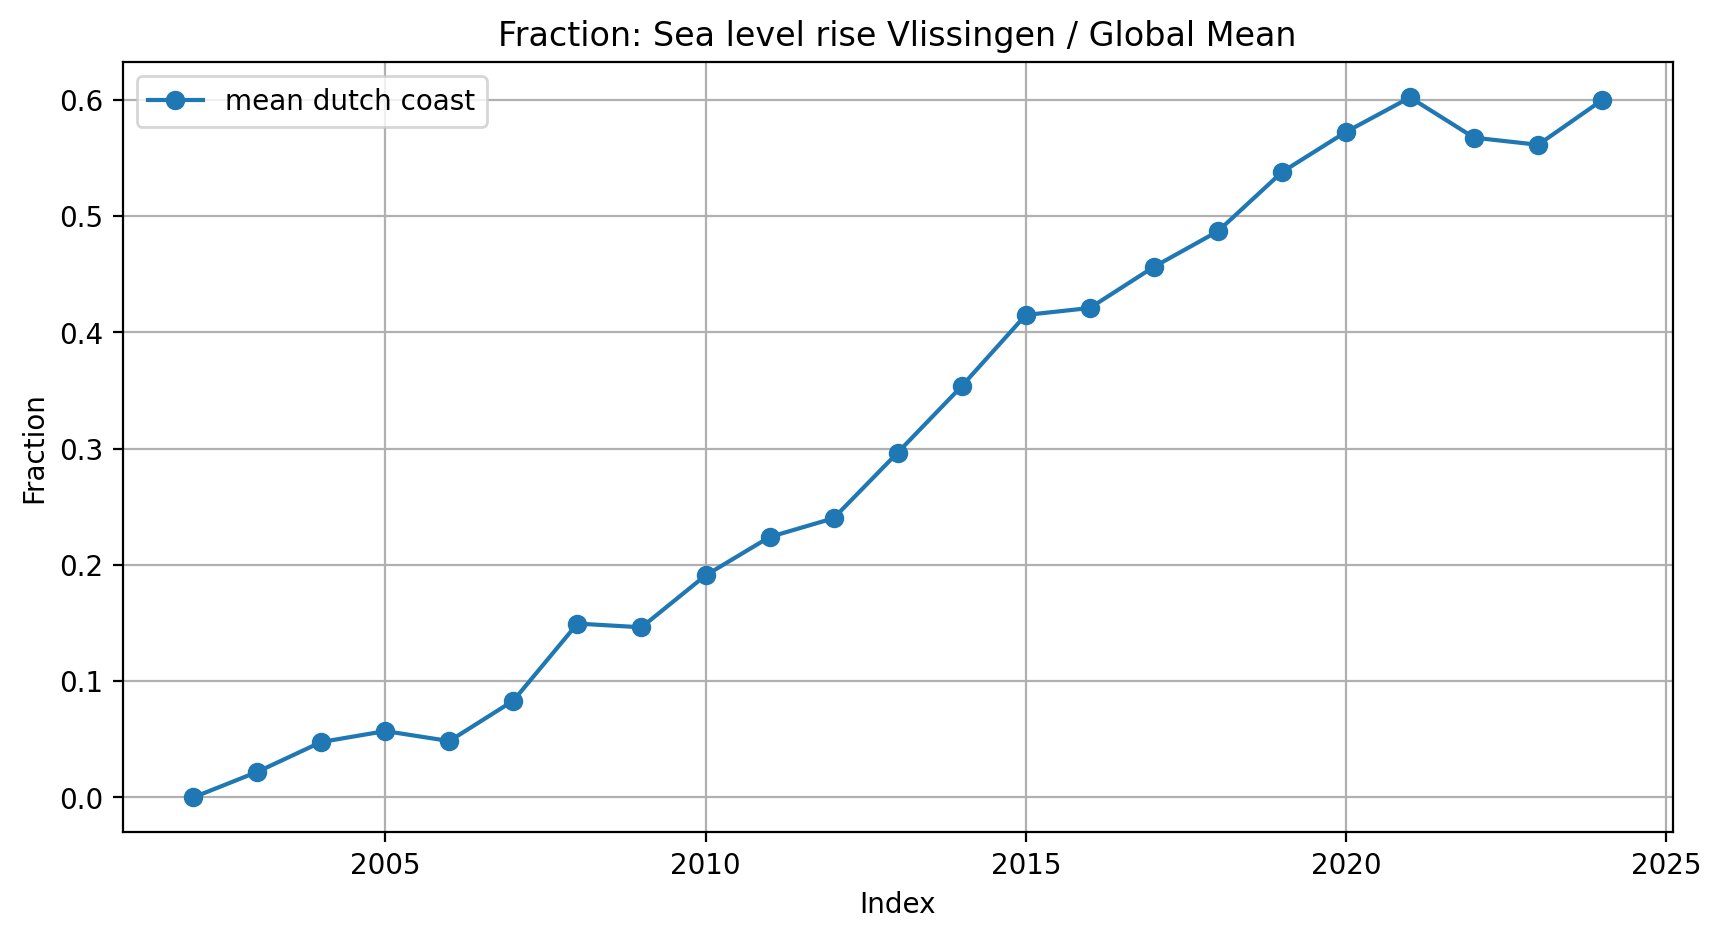

In [39]:
#display(GRAVANT)
fraction = GRAVANT['Ant_gravis']/Gravis_ant_ds['Meanslr'] 
#display(fraction)


# Combine the three values into one DataFrame
combined = pd.DataFrame({
    'Sea level rise vlissingen': GRAVANT['Ant_gravis'],
    'Sea level rise dutch coast': mean_df_filtered['Ant_gravis_mean'], 
    'Mean sea level rise': Gravis_ant_ds['Meanslr'],
    'Fraction (sea level rise / global mean )': GRAVANT['Ant_gravis'] / Gravis_ant_ds['Meanslr'],
    'Fraction (sea level rise dutch / global mean )': mean_df_filtered['Ant_gravis_mean']/ Gravis_ant_ds['Meanslr']
})

#display(combined['Fraction (sea level rise / global mean )'])
display(combined)

        

# Drop rows where the fraction is NaN
valid_data = combined.dropna(subset=['Fraction (sea level rise / global mean )'])
valid_data2 = combined.dropna(subset=['Mean sea level rise'])
valid_data3 = combined.dropna(subset=['Sea level rise vlissingen'])
#valid_data4 = combined.dropna(subset=['Sea level rise dutch coast'])
#valid_data5 = combined.dropna(subset=['Fraction (sea level rise dutch / global mean )'])

# Plot the fraction
plt.figure(figsize=(10, 5))
#plt.plot(valid_data.index, valid_data['Fraction (sea level rise / global mean )'], marker='o', label='fraction')
plt.plot(valid_data2.index, valid_data2['Mean sea level rise'], marker='o', label='mean dutch coast')
#plt.plot(valid_data3.index, valid_data3['Sea level rise vlissingen'], marker='o', label='vlissingen')

plt.title('Fraction: Sea level rise Vlissingen / Global Mean')
plt.xlabel('Index')
plt.ylabel('Fraction')
plt.grid(True)
plt.legend()
plt.show()

In [40]:
# Test for in sealevelcontrib


fredant_df = slc.contrib_frederikse2020(tg_coord, 'AIS',
                                extrap=True)



Gravis_dir = '../outputs/Gravis_Antarctica/'
Gravis_ant_ds = xr.open_dataset(f'{Gravis_dir}Gravis_Ant_new_weighted.nc')
sel_da = Gravis_ant_ds['AIS_Gravis'].ffill('lon', 3).bfill('lon', 3)

loc_da = sel_da.sel(lat = tg_coord[0], 
                    lon = tg_coord[1], 
                    method = 'nearest')
fr_name = {
    'tws' : 'TWS', 
    'AIS' : 'Antarctica', 
    'GrIS' : 'Greenland', 
    'glac' : 'Glaciers',
    'grav': 'Ant_gravis'}
ant_df = loc_da.squeeze().reset_coords(drop=True).to_dataframe(name=fr_name['grav']) 
ant_df = ant_df*1.2 #for now corrected... 

# now combine the two by taking frederikse for data before 2002, taking the 
display(fredant_df.loc[2002:])
#print(ant_df.loc[2002:])


,Antarctica
time,
2002,-0.250000
2003,-0.220000
2004,-0.175000
2005,-0.185000
2006,-0.210000
2007,-0.155000
2008,-0.075000
2009,-0.090000
2010,-0.015000


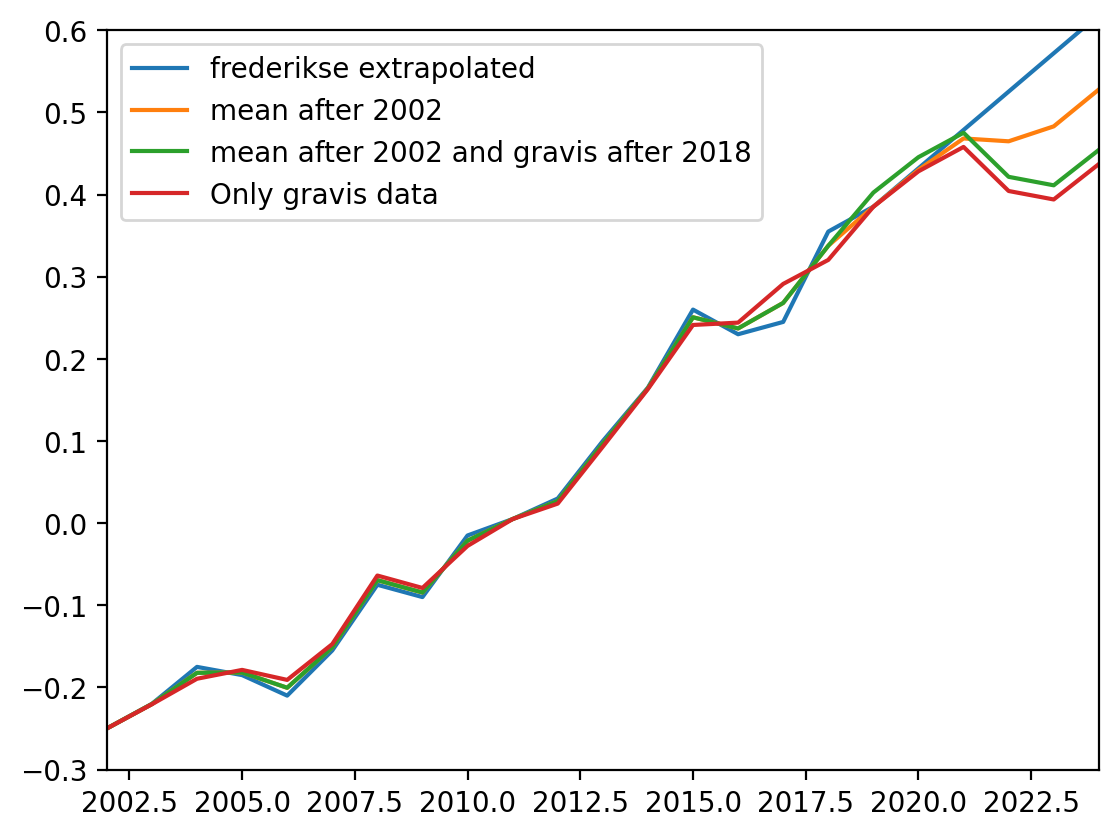

<class 'pandas.core.series.Series'>
<class 'pandas.core.frame.DataFrame'>


time
1900   -0.845000
1901   -0.840000
1902   -0.835000
1903   -0.830000
1904   -0.830000
          ...   
2021    0.475326
2022    0.421666
2023    0.411335
2024    0.454408
2025         NaN
Name: Antarctica, Length: 126, dtype: float64

In [41]:
#Ant_combined = mean_df['Antarctica_mean'].copy()
#Ant_combined.loc[2002:] = ((mean_df['Ant_gravis_mean'] + mean_df['Antarctica_mean'].loc[2002]) + mean_df['Antarctica_mean'])/2  #takes the mean where there is data twice
#Ant_combined.loc[2018:] = mean_df['Ant_gravis_mean'] - mean_df['Ant_gravis_mean'].loc[2018] + Ant_combined.loc[2018]  # from 2018, take gravis data but force 2018 on the mean
#fredant_df = mean_df['Antarctica_mean']
#ant_df = mean_df['ant_gravis_mean']


Antcombi = fredant_df['Antarctica'].copy()
plt.plot(Antcombi, label='frederikse extrapolated')
Antcombi.loc[2002:] = ((ant_df['Ant_gravis'] + fredant_df['Antarctica'].loc[2002]) + fredant_df['Antarctica'])/2
plt.plot(Antcombi, label= 'mean after 2002')
Antcombi.loc[2018:] = ant_df['Ant_gravis'] - ant_df['Ant_gravis'].loc[2018] + Antcombi.loc[2018] 
plt.plot(Antcombi, label= 'mean after 2002 and gravis after 2018')
plt.plot(ant_df['Ant_gravis'] + fredant_df['Antarctica'].loc[2002], label='Only gravis data')
plt.xlim(2002, 2024)
plt.ylim(-0.3, 0.6)
plt.legend()
plt.show()
#display(mean_df['Ant_gravis_mean'])
#display(ant_df['Ant_gravis'])
print(type(Antcombi))
print(type(ant_df))
display(Antcombi)
Antcombi = Antcombi.to_frame()

#display(Antcombi)


#is it datarame or xr